hello there, today I'll try to made a classification model that class the email between spam or not spam, I still don't know what I will use or what algorithm, I'll search and asking AI, the past time I built a model that predict the price of a house, and I used liniar regression because I have numerical value and I try to predict, I used the OneHotEncoding to convert categoriel parametres to numerical, I learned a lot and I'll learn more in this project.
by the way, you can check the House Pricing project here: https://github.com/issamsensi/HousePricing

I know that the first the thing and the important thing in the build of a model is the data processing, it's the third step in a machine learning project, the first thing is to understand the domain.
first- domain understanding: it's easy here, we want to send an email to someone and we want to see if this email will go to inbox or spam, so we should know before to edit it if it is spam.
second- data collecting: I installed a dataset from kaggle, I thik it's good.
third and important- data processing: that what I'll do in this file, we'll see if there is null values, we'll study the relationshp between parametres also, we'll clean the data by removing or remplacing the manquantes or outliers, but in this dataset I think that I'll just clean the message text.
forth- data preparing: I think we can encluding the feature engineering in this step, we'll chose the best features that impact the model, again there is no much in my dataset, just message and category.
fifth- train and test: we'll split the data to 80% for training the model and 20% to test and evaluate it, if it pass the evaluation we can pass the final step, else we'll go back to precident step and 90% the third-(data processing)
finally- deployment: I didn't try this one before, but after we train the model and pass the test great we can deploy it to real life using docker or a hosting service or claud .....

after writing all this bullshit we can pass to the real work (I'm the bullshit here)

In [1]:
# first thing libraries importing

import pandas as pd
import numpy as np

# I don't know where can I use the visualisation in this project
import seaborn as sns
import matplotlib.pyplot as plt

import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import confusion_matrix


In [2]:
# importing the data and explore it

data = pd.read_csv('email.csv')

data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(data.shape, '\n')
print(data.isnull().sum(), '\n')
print(data.describe(), '\n')
print(data.info())

(5572, 2) 

Category    0
Message     0
dtype: int64 

       Category                 Message
count      5572                    5572
unique        2                    5157
top         ham  Sorry, I'll call later
freq       4825                      30 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

'''
cleaned_emails = [clean_text(i) for i in data['Message']]
cat = [j for j in data['Category']]
df = []

for i, j in zip(cat,cleaned_emails):
    df.append({
        'Category': i,
        'Message': j
    })

new_data = pd.DataFrame(df)
'''

data['Message'] = data['Message'].apply(clean_text)
new_data = data

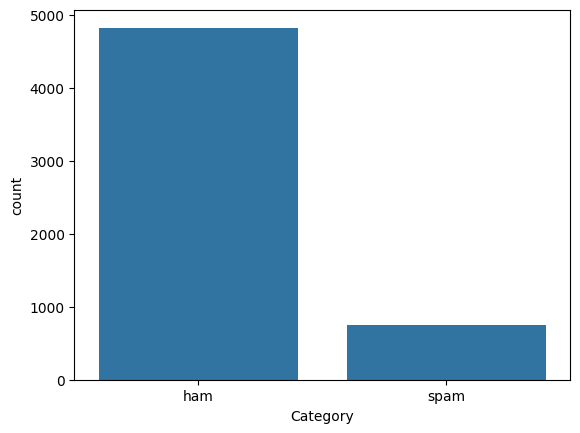

In [5]:
sns.countplot(x='Category', data=new_data)
plt.show()

In [15]:
# let's try to train this model

y = new_data['Category']     
x = new_data['Message']       

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=35)

vectorizer = TfidfVectorizer(stop_words='english')
x_train_tfidf = vectorizer.fit_transform(x_train)  
x_test_tfidf = vectorizer.transform(x_test)        

model = MultinomialNB()
model.fit(x_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [7]:
print(x_test_tfidf)
print(x_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7110 stored elements and shape (1115, 7263)>
  Coords	Values
  (0, 127)	0.2648625277948577
  (0, 663)	0.3001597620385796
  (0, 1209)	0.3050664372396714
  (0, 2255)	0.17606194010983492
  (0, 2459)	0.19225288398889237
  (0, 2720)	0.20470277746875642
  (0, 3244)	0.34592640103189504
  (0, 3445)	0.3106291667881731
  (0, 3785)	0.22112841825073867
  (0, 4110)	0.1873462087878006
  (0, 4162)	0.2056496043636904
  (0, 5351)	0.5425684555534666
  (1, 242)	0.4870951515324758
  (1, 2083)	0.37440543444529517
  (1, 2494)	0.23359543003447805
  (1, 2940)	0.19823843521238094
  (1, 3502)	0.4170304868524625
  (1, 5039)	0.28667571137376663
  (1, 5728)	0.4358487429997638
  (1, 7187)	0.2874579354486614
  (2, 30)	0.8076879484481156
  (2, 2470)	0.5896101915093346
  (3, 410)	0.2571393346416423
  (3, 722)	0.296155435804232
  (3, 1076)	0.35966743618942915
  :	:
  (1108, 599)	0.42062811165983754
  (1108, 1765)	0.37914978456734116
  (1108, 2637)	0.35156866

In [ ]:
# let's try
y_pred = model.predict(x_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

Accuracy: 0.9533632286995516
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       951
        spam       1.00      0.68      0.81       164

    accuracy                           0.95      1115
   macro avg       0.97      0.84      0.89      1115
weighted avg       0.96      0.95      0.95      1115

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [17]:
# let's try and test an email
messages = [
"win a free iphone now",
"earn money fast",
"hello how are you"
]

messages = [clean_text(m) for m in messages]
test_tfidf = vectorizer.transform(messages)
pred = model.predict(test_tfidf)

print(test_tfidf)
print(pred)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (3, 7263)>
  Coords	Values
  (0, 2255)	0.6085662496076161
  (0, 7008)	0.7935030685753651
  (1, 1785)	0.6865257965156838
  (1, 2055)	0.5652953979154965
  (1, 3949)	0.4573001681762938
  (2, 2692)	1.0
['spam' 'ham' 'ham']


a brilliant discovery just now, I accidently do text = re.sub(r'\s+', '', text) in place text = re.sub(r'\s+', ' ', text) and accuracy is 0.86 and the model can't classify the email correctly, but when I fixed the error the accuracy increase to 0.95, and this shows how data processing (data cleaning) is very important.

In [10]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[951   0]
 [ 52 112]]


here we can say that the model is good at ham, It predict 951 from 951 correctly, but in spam there is 52 message spam but he says that it's ham, but acctualy this is good, spam go to inbox much better than ham goes to spam, and it's predict 112 correctly, and the problem is that we have almost 4800 email ham and just 800 spam in our dataset, and this explain all.

In [11]:
feature_names = vectorizer.get_feature_names_out()

spam_probs = model.feature_log_prob_[1]

top_spam = sorted(zip(spam_probs, feature_names), reverse=True)[:20]

print(top_spam)

[(np.float64(-5.740025309665572), 'free'), (np.float64(-6.084245112795498), 'txt'), (np.float64(-6.106446856493398), 'claim'), (np.float64(-6.122093446109344), 'mobile'), (np.float64(-6.2066254297475645), 'text'), (np.float64(-6.2183453618662945), 'stop'), (np.float64(-6.227047992826494), 'ur'), (np.float64(-6.260598227012336), 'prize'), (np.float64(-6.371459189805712), 'reply'), (np.float64(-6.437317311877866), 'won'), (np.float64(-6.4864110457310495), 'urgent'), (np.float64(-6.54961280417835), 'nokia'), (np.float64(-6.573347644130056), 'new'), (np.float64(-6.578656659411871), 'contact'), (np.float64(-6.6128635763325025), 'cash'), (np.float64(-6.688461491628045), 'service'), (np.float64(-6.709753681976709), 'send'), (np.float64(-6.74215267684902), 'win'), (np.float64(-6.779298070116581), 'guaranteed'), (np.float64(-6.783051819245266), 'customer')]


another observation, we use vectorizer.fit_transform to train the model in words, but just vectorizer.transform to use the same words in the test. we can't use fit in both of them and this is wrong.